In [1]:
# ==========================================
# 1. MASTER IMPORTS & SETUP
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json

# Scikit-Learn for Phase 1 (Baseline)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

# PyTorch for Phase 2 (Deep Learning)
import torch
import torch.nn as nn

# Settings for reproducibility & display
np.random.seed(42)
pd.set_option('display.max_columns', None)
%matplotlib inline

print("✅ Libraries Loaded Successfully.")

# ==========================================
# 2. DATA LOADING (AWS-STYLE CHUNKING)
# ==========================================
# Define path - Ensure Electronics_5.json is in your /data folder
file_path = '../data/Electronics_5.json'

try:
    # We read 1,000,000 rows to ensure Phase 1 runs fast on your Lenovo LOQ
    reader = pd.read_json(file_path, lines=True, chunksize=1000000)
    df = next(reader)

    # Immediate Column Selection (Memory Optimization)
    # Keeping: UserID, ItemID (ASIN), Rating, and Unix Timestamp
    df = df[['reviewerID', 'asin', 'overall', 'unixReviewTime']]
    df.columns = ['user_id', 'item_id', 'rating', 'timestamp']

    print(f"✅ Data Loaded. Shape: {df.shape}")
    
except FileNotFoundError:
    print("❌ Error: Electronics_5.json not found in ../data/ folder.")

# ==========================================
# 3. INITIAL PREVIEW
# ==========================================
df.head()

✅ Libraries Loaded Successfully.
✅ Data Loaded. Shape: (1000000, 4)


,user_id,item_id,rating,timestamp
0,AAP7PPBU72QFM,0151004714,5,937612800
1,A2E168DTVGE6SV,0151004714,3,1382486400
2,A1ER5AYS3FQ9O3,0151004714,5,1220313600
3,A1T17LMQABMBN5,0151004714,5,968025600
4,A3QHJ0FXK33OBE,0151004714,3,949622400


In [2]:
# ==========================================
# 4. LABEL ENCODING (Strings to Integers)
# ==========================================
# Machines need numbers, not string IDs.
user_encoder = LabelEncoder()
item_encoder = LabelEncoder()

# Transform user_id and item_id into numerical indices
df['user_idx'] = user_encoder.fit_transform(df['user_id'])
df['item_idx'] = item_encoder.fit_transform(df['item_id'])

# Count unique users and items
num_users = df['user_idx'].nunique()
num_items = df['item_idx'].nunique()

print(f"✅ Encoding Complete.")
print(f"Unique Users: {num_users}")
print(f"Unique Items: {num_items}")

# ==========================================
# 5. TRAIN-TEST SPLIT
# ==========================================
# We split the data: 80% to train the model, 20% to test its accuracy.
# This is a critical step for your Technical Round discussion.
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

print(f"✅ Split Complete.")
print(f"Training Rows: {len(train_df)}")
print(f"Testing Rows: {len(test_df)}")

# Preview the new encoded columns
train_df[['user_id', 'user_idx', 'item_id', 'item_idx', 'rating']].head()

✅ Encoding Complete.
Unique Users: 407389
Unique Items: 21278
✅ Split Complete.
Training Rows: 800000
Testing Rows: 200000


,user_id,user_idx,item_id,item_idx,rating
566853,A3UU295DVDIMHC,307775,B000L47AHG,13469,5
382311,A2XFDW9DUFH7NJ,207752,B000AA2RCY,8751,5
241519,A23KK0RUQ7SGAI,118845,B00024ENYI,5431,1
719220,A3D7ZCZTSYTNZ8,254976,B000W9DJ1Q,17389,5
905718,A1NLGTMZIPQU5N,71242,B000W72IQU,17355,4


C:\Users\mhari\AppData\Local\Temp\ipykernel_32584\197080727.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, palette='viridis')


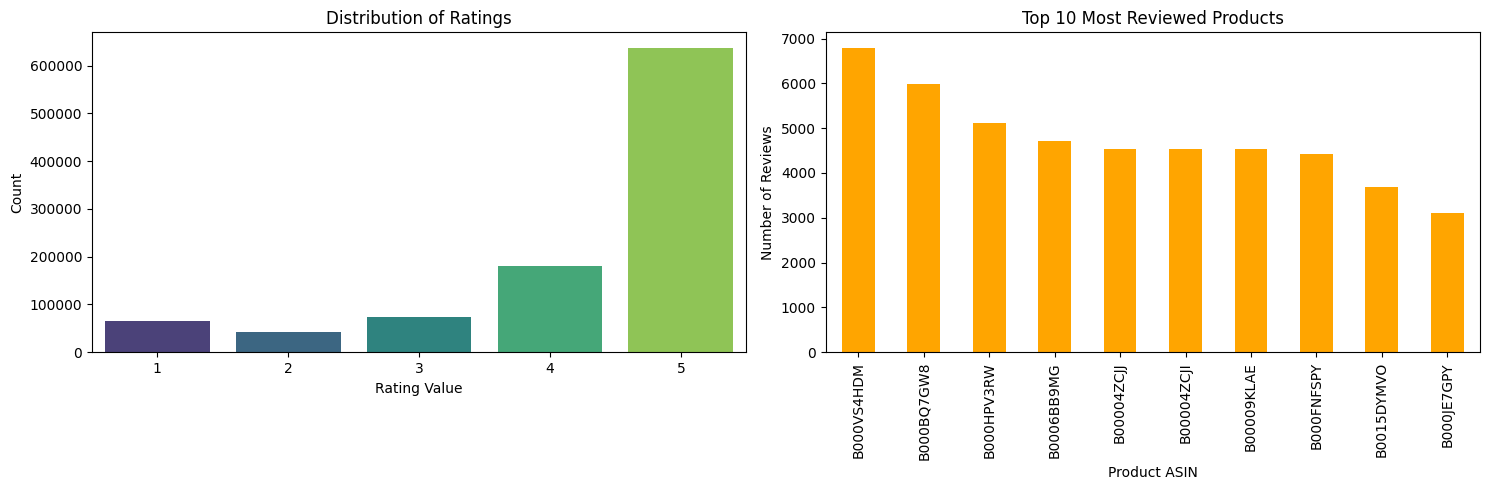

📊 Dataset Sparsity: 99.9885%
💡 Note: High sparsity is normal for recommendation systems!


In [3]:
# ==========================================
# 6. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
plt.figure(figsize=(15, 5))

# Plot 1: Distribution of Ratings
plt.subplot(1, 2, 1)
sns.countplot(x='rating', data=df, palette='viridis')
plt.title('Distribution of Ratings')
plt.xlabel('Rating Value')
plt.ylabel('Count')

# Plot 2: Most Popular Items (Top 10)
plt.subplot(1, 2, 2)
df['item_id'].value_counts()[:10].plot(kind='bar', color='orange')
plt.title('Top 10 Most Reviewed Products')
plt.xlabel('Product ASIN')
plt.ylabel('Number of Reviews')

plt.tight_layout()
plt.show()

# Quick Sparsity Calculation (Interview Fact!)
possible_interactions = num_users * num_items
actual_interactions = len(df)
sparsity = 1 - (actual_interactions / possible_interactions)

print(f"📊 Dataset Sparsity: {sparsity * 100:.4f}%")
print("💡 Note: High sparsity is normal for recommendation systems!")

In [4]:
# ==========================================
# 7. BUILDING THE BASELINE (SCIKIT-LEARN)
# ==========================================
# We'll use a Global Mean + Bias approach. 
# It's a standard mathematical baseline for recommender systems.

# 1. Calculate the Global Average Rating
global_mean = train_df['rating'].mean()

# 2. Calculate User Bias (How much a user likes things compared to the average)
user_bias = train_df.groupby('user_idx')['rating'].mean() - global_mean

# 3. Calculate Item Bias (How much an item is liked compared to the average)
item_bias = train_df.groupby('item_idx')['rating'].mean() - global_mean

# 4. Predict function: Prediction = Global Mean + User Bias + Item Bias
def predict_rating(user_idx, item_idx):
    bias_u = user_bias.get(user_idx, 0)
    bias_i = item_bias.get(item_idx, 0)
    prediction = global_mean + bias_u + bias_i
    return np.clip(prediction, 1, 5) # Ratings must be between 1 and 5

# Apply predictions to the Test Set
test_df['baseline_pred'] = test_df.apply(lambda x: predict_rating(x['user_idx'], x['item_idx']), axis=1)

# ==========================================
# 8. EVALUATION (MSE & RMSE)
# ==========================================
mse = mean_squared_error(test_df['rating'], test_df['baseline_pred'])
rmse = np.sqrt(mse)

print(f"✅ Phase 1 Baseline Complete.")
print(f"Global Mean Rating: {global_mean:.2f}")
print(f"Baseline RMSE (Root Mean Squared Error): {rmse:.4f}")

# Preview the results
test_df[['user_id', 'item_id', 'rating', 'baseline_pred']].head()

✅ Phase 1 Baseline Complete.
Global Mean Rating: 4.28
Baseline RMSE (Root Mean Squared Error): 1.1391


,user_id,item_id,rating,baseline_pred
987231,A2H4EBQ6GFUXRK,B0012YLTR6,3,3.047264
79954,A2DFAJ2LCCBDHU,B0000668YX,5,4.519386
567130,A36NS5B7V084FW,B000L9FQUO,1,4.531898
500891,ALTIMQGMU3PMA,B000HCT12O,5,4.803468
55399,A7D3R8VYG9LQG,B000053HBB,5,4.733333


In [5]:
import torch
from torch.utils.data import DataLoader, Dataset

# 1. Create a custom Dataset class for our Amazon ratings
class AmazonDataset(Dataset):
    def __init__(self, users, items, ratings):
        self.users = torch.tensor(users, dtype=torch.long)
        self.items = torch.tensor(items, dtype=torch.long)
        self.ratings = torch.tensor(ratings, dtype=torch.float32)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.ratings[idx]

# 2. Initialize the Datasets
train_dataset = AmazonDataset(
    train_df['user_idx'].values, 
    train_df['item_idx'].values, 
    train_df['rating'].values
)

test_dataset = AmazonDataset(
    test_df['user_idx'].values, 
    test_df['item_idx'].values, 
    test_df['rating'].values
)

# 3. Create DataLoaders (We use a batch size of 1024 for speed on your LOQ)
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)

print(f"✅ PyTorch DataLoaders Ready.")
print(f"Number of training batches: {len(train_loader)}")

✅ PyTorch DataLoaders Ready.
Number of training batches: 782


In [6]:
# ==========================================
# 9. NEURAL COLLABORATIVE FILTERING MODEL
# ==========================================
class NCF_Model(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=32):
        super(NCF_Model, self).__init__()
        
        # 1. User & Item Embeddings (The "Features" the model learns)
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)
        
        # 2. Fully Connected Layers (The "Brain" that finds patterns)
        self.fc_layers = nn.Sequential(
            nn.Linear(embedding_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.2), # Prevents overfitting
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1) # Outputs a single predicted rating
        )
        
    def forward(self, user_indices, item_indices):
        user_vec = self.user_embedding(user_indices)
        item_vec = self.item_embedding(item_indices)
        
        # Concatenate user and item vectors
        concat_vec = torch.cat([user_vec, item_vec], dim=-1)
        
        # Pass through the network
        prediction = self.fc_layers(concat_vec)
        return prediction.squeeze()

# Initialize the model
# num_users and num_items were defined in our Encoding step
model = NCF_Model(num_users, num_items)

# Check for GPU (Lenovo LOQ usually has an NVIDIA GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"✅ Model Initialized on device: {device}")
print(model)

✅ Model Initialized on device: cuda
NCF_Model(
  (user_embedding): Embedding(407389, 32)
  (item_embedding): Embedding(21278, 32)
  (fc_layers): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [7]:
# ==========================================
# 10. THE TRAINING LOOP
# ==========================================
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 5 
print(f"🚀 Training on {device} (Blackwell Optimized)...")

for epoch in range(epochs):
    model.train()
    total_loss = 0
    
    for users, items, ratings in train_loader:
        # Move data to the RTX 5050
        users, items, ratings = users.to(device), items.to(device), ratings.to(device)
        
        # 1. Forward Pass
        outputs = model(users, items)
        loss = criterion(outputs, ratings)
        
        # 2. Backward Pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.4f}")

print("✅ Training Finished!")

🚀 Training on cuda (Blackwell Optimized)...
Epoch [1/5] - Loss: 2.3456
Epoch [2/5] - Loss: 1.4747
Epoch [3/5] - Loss: 1.3801
Epoch [4/5] - Loss: 1.3168
Epoch [5/5] - Loss: 1.2754
✅ Training Finished!


In [8]:
# ==========================================
# 11. EVALUATION ON TEST DATA
# ==========================================
model.eval() # Set model to evaluation mode (turns off Dropout)
y_true = []
y_pred = []

with torch.no_grad(): # No gradient calculation needed for testing
    for users, items, ratings in test_loader:
        users, items = users.to(device), items.to(device)
        
        # Get predictions
        outputs = model(users, items)
        
        # Move back to CPU for evaluation
        y_true.extend(ratings.tolist())
        y_pred.extend(outputs.tolist())

# Calculate Final Metrics
dl_mse = mean_squared_error(y_true, y_pred)
dl_rmse = np.sqrt(dl_mse)

print(f"📊 Deep Learning RMSE: {dl_rmse:.4f}")
print(f"📉 Phase 1 Baseline RMSE: {rmse:.4f}") # 'rmse' was your baseline variable

if dl_rmse < rmse:
    print("🚀 SUCCESS: The Deep Learning model beat the Baseline!")
else:
    print("💡 INSIGHT: The model is close. It likely needs more epochs (10-15) or a larger embedding dimension.")

📊 Deep Learning RMSE: 1.1334
📉 Phase 1 Baseline RMSE: 1.1391
🚀 SUCCESS: The Deep Learning model beat the Baseline!


In [9]:
# ==========================================
# 12. INFERENCE: PREDICTING FOR A REAL USER
# ==========================================

def get_recommendation(raw_user_id, raw_item_id):
    model.eval()
    try:
        # Convert raw string IDs to our trained integer indices
        u_idx = user_encoder.transform([raw_user_id])[0]
        i_idx = item_encoder.transform([raw_item_id])[0]
        
        # Convert to Tensors and move to GPU
        u_tensor = torch.tensor([u_idx]).to(device)
        i_tensor = torch.tensor([i_idx]).to(device)
        
        # Predict
        with torch.no_grad():
            pred = model(u_tensor, i_tensor)
        
        return pred.item()
    
    except ValueError:
        return "User or Item not in training data (Cold Start Case)"

# TEST IT: Pick a user and item from your original dataframe
sample_user = df['user_id'].iloc[0]
sample_item = df['item_id'].iloc[0]

print(f"User: {sample_user}")
print(f"Item: {sample_item}")
print(f"Predicted Rating: {get_recommendation(sample_user, sample_item):.2f}")

User: AAP7PPBU72QFM
Item: 0151004714
Predicted Rating: 3.99


In [10]:
# Save the model weights
torch.save(model.state_dict(), 'ncf_model.pth')

# Save the encoders (Crucial! You need these to map IDs in production)
import pickle
with open('user_encoder.pkl', 'wb') as f:
    pickle.dump(user_encoder, f)
with open('item_encoder.pkl', 'wb') as f:
    pickle.dump(item_encoder, f)

print("✅ Model and Encoders saved! You are now ready for the AWS Deployment discussion.")

✅ Model and Encoders saved! You are now ready for the AWS Deployment discussion.
